In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
import torch

sys.path.insert(0, os.path.abspath("../.."))

from network.QAN3D import Torus3DQAN
from network.torch_backend import TorchBackend
from network.visualize3D import visualize_trajectory_projections, plot_pi_error, neuron_counts
from metrics import wrapped_angle_diff
from config import RunConfig


# Setup

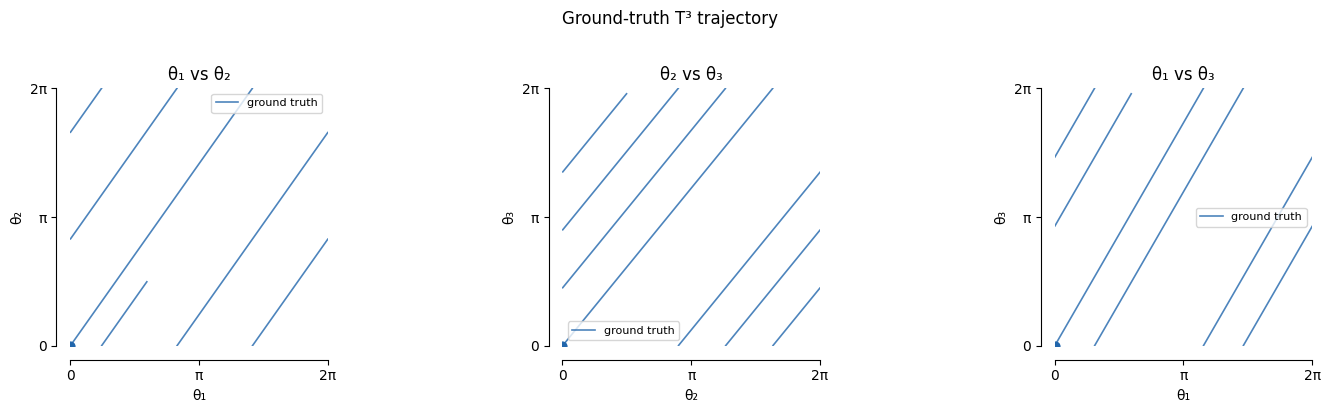

In [2]:
cfg = RunConfig()
qan_sim = Torus3DQAN(
    spacing=0.3,            # neuron density on manifold
    lambda_net=2.5,         # kernel wavelength
    ratio=1.05,             # sigma_e / sigma_i ratio (DoG width balance)
    target_margin=3.0,      # how far above Turing instability threshold
    b=0.3,                  # baseline drive (keeps all neurons weakly active)
    offset_magnitude=0.19,  # δ for push-pull offset kernels
    build_connectivity=False # FFT path or dense matrox
)

# Generate the ground-truth trajectory on T^3
trajectory = qan_sim.make_trajectory(n_steps=5000)

fig, _ = visualize_trajectory_projections(
    trajectory,
    title="Ground-truth T³ trajectory"
)
plt.show()

# Simulate and decode 

peak_phase range per axis: [5.98398601 1.1967972  1.7951958 ]
peak_phase[0]: [0. 0. 0.]  peak_phase[-1]: [0. 0. 0.]


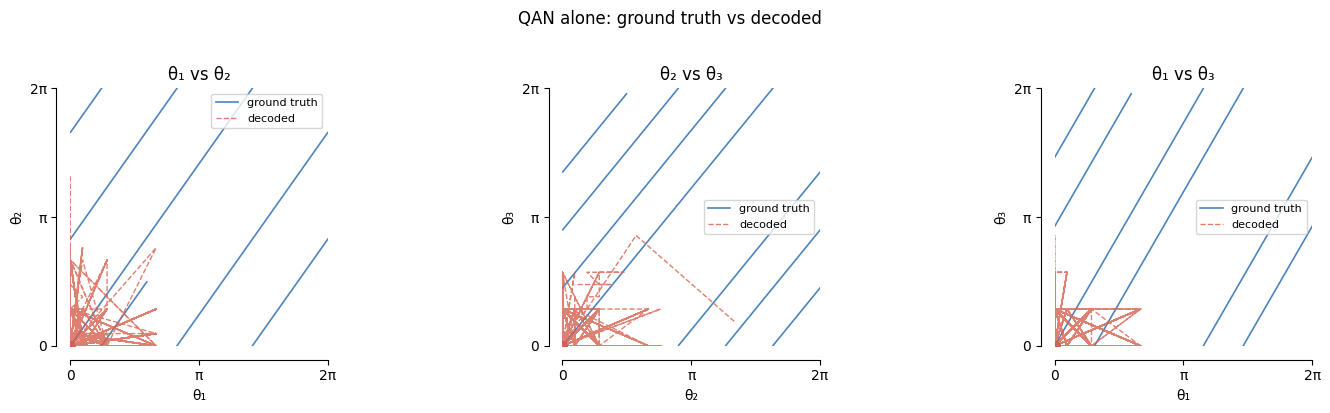

In [3]:
backend = TorchBackend(qan_sim)

decoded, states = backend.simulate(trajectory, decode="phase", return_states=True)

ref_can = qan_sim.cans[0]
n1, n2, n3 = ref_can.nx(0), ref_can.nx(1), ref_can.nx(2)
coords_3d = ref_can.neurons_coordinates.reshape(n1, n2, n3, 3)

peak_phase = np.zeros((states.shape[0], 3))
for t in range(states.shape[0]):
    ref_idx = int(np.argmax(states[t]))
    i1, i2, i3 = np.unravel_index(ref_idx, (n1, n2, n3))
    peak_phase[t] = coords_3d[i1, i2, i3]

# Does the RAW state even move, regardless of any decoder?
print("peak_phase range per axis:", peak_phase.max(axis=0) - peak_phase.min(axis=0))
print("peak_phase[0]:", peak_phase[0], " peak_phase[-1]:", peak_phase[-1])

# Overlay decoded trajectory on ground truth 
fig, _ = visualize_trajectory_projections(
    trajectory, decoded=decoded,
    title="QAN alone: ground truth vs decoded"
)
plt.show()

In [4]:
# Total trajectory length (sum of per-step displacements)
steps = np.linalg.norm(wrapped_angle_diff(trajectory[1:], trajectory[:-1]), axis=1)
traj_length = np.cumsum(steps)

# Normalized error = cumulative_error / distance_traveled
err = np.linalg.norm(wrapped_angle_diff(decoded, trajectory), axis=1)
normalized_err = err[1:] / (traj_length + 1e-9)

print(f"Normalized error (MADE metric): {np.mean(normalized_err):.4f}")

gt_vel  = wrapped_angle_diff(trajectory[1:], trajectory[:-1])
dec_vel = wrapped_angle_diff(decoded[1:],    decoded[:-1])
num = (dec_vel * gt_vel).sum(1)
den = np.linalg.norm(dec_vel, axis=1) * np.linalg.norm(gt_vel, axis=1) + 1e-12
print("direction cos (QAN alone):", round(np.median(num/den), 3))   # want ≈ 1

Normalized error (MADE metric): 0.3215
direction cos (QAN alone): 0.0


In [5]:
err_peak = np.linalg.norm(wrapped_angle_diff(peak_phase, trajectory), axis=1)
normalized_err_peak = err_peak[1:] / (traj_length + 1e-9)

gt_vel = wrapped_angle_diff(trajectory[1:], trajectory[:-1])
peak_vel = wrapped_angle_diff(peak_phase[1:], peak_phase[:-1])
num = (peak_vel * gt_vel).sum(1)
den = np.linalg.norm(peak_vel, axis=1) * np.linalg.norm(gt_vel, axis=1) + 1e-12

print(f"Normalized error (peak-tracking):   {np.mean(normalized_err_peak):.4f}")
print(f"direction cos (peak-tracking):      {np.median(num/den):.3f}")

Normalized error (peak-tracking):   0.3246
direction cos (peak-tracking):      0.000


In [6]:
for idx in [0, 2, 4]:  # one CAN from each axis pair
    can = qan_sim.cans[idx]
    print(idx, "connectivity built:", hasattr(can, "connectivity_matrix"),
          "S shape:", can.S.shape,
          "S std after reset:", can.S.std())

0 connectivity built: False S shape: (9261, 1) S std after reset: 0.0
2 connectivity built: False S shape: (9261, 1) S std after reset: 0.0
4 connectivity built: False S shape: (9261, 1) S std after reset: 0.0


In [7]:
backend.reset(np.array([0.0, 0.0, 0.0]), radius=0.05)

pure_axis3_drive = np.array([0.0, 0.0, 0.01], dtype=np.float32)

n1 = n2 = n3 = backend.n
coords_3d = backend.coords.cpu().numpy().reshape(n1, n2, n3, 3)

peak_positions = []
for step in range(200):
    S_tot = torch.mean(backend.S, dim=0)
    backend.step_from_shared_state(S_tot, pure_axis3_drive)
    S_now = torch.mean(backend.S, dim=0).squeeze()
    idx = int(torch.argmax(S_now))
    i1, i2, i3 = np.unravel_index(idx, (n1, n2, n3))
    peak_positions.append(coords_3d[i1, i2, i3])

peak_positions = np.array(peak_positions)
print("axis 3 peak position over time (every 20 steps):")
print(peak_positions[::20, 2])
print("axis 1,2 peak position (should stay ~0 if isolation is clean):")
print(peak_positions[::20, :2])

axis 3 peak position over time (every 20 steps):
[0.        0.        0.        1.1967973 1.4959965 1.7951958 1.7951958
 1.7951958 1.7951958 1.7951958]
axis 1,2 peak position (should stay ~0 if isolation is clean):
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
